In [ ]:
from g2p_en import G2p
import torch
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
plt.rcParams['figure.constrained_layout.use'] = True

from torch import nn

import rootutils
root = rootutils.setup_root(
    search_from=".",
    indicator=".project-root",
    pythonpath=True
)

from src.utils import syllabifier
from src.utils.preprocess_utils import clean_and_normalize_text, word_norm

stops = set(stopwords.words('english'))  
g2p = G2p()
language = syllabifier.English # syllabifier.loadLanguage("english.cfg")

In [2]:
def get_phone_dict():

    vowel_base = ['AA', 'AE', 'AH', 'AO', 'AW', 'AY', 'EH', 'ER', 'EY', 'IH', 'IY', 'OW', 'OY', 'UH', 'UW']
    vowel_stress = ['0', '1', '2']
    consonants = ['B', 'CH', 'D', 'DH' , 'F', 'G', 'HH', 'JH', 'K', 'L', 'M', 'N', 'NG', 'P', 'R', 'S', 
                'SH', 'T', 'TH', 'V', 'W', 'Y', 'Z', 'ZH'] 
    consonants_onset = [consonant + '_onset' for consonant in consonants]
    consonants_coda = [consonant + '_coda' for consonant in consonants]

    phone_dict = consonants_onset + vowel_base + vowel_stress + consonants_coda # 15+3+24+24=66

    return phone_dict, vowel_base, vowel_stress, consonants

In [3]:
def sylphone_feature_idx():
    
    phone_list, vowels, stresses, consonants = get_phone_dict()
    
    le = LabelEncoder()  
    label_encode = le.fit_transform(phone_list)
    label_mapping = dict(enumerate(le.classes_))
    label_encode = torch.from_numpy(label_encode)

    cons_onset = [item+'_onset' for item in consonants]
    cons_coda = [item+'_coda' for item in consonants]

    conso_onset_idx = torch.tensor([[key for key, val in label_mapping.items() 
                                if val == value][0] for value in cons_onset])
    conso_coda_idx = torch.tensor([[key for key, val in label_mapping.items()
                                if val == value][0] for value in cons_coda])
    vowel_idx = torch.tensor([[key for key, val in label_mapping.items()
                                if val == value][0] for value in vowels])
    stresses = ['0', '1', '2']
    stress_idx = torch.tensor([[key for key, val in label_mapping.items()
                                if val == value][0] for value in stresses])

    # long vowels: AA, AO, AW, AY, EY, IY, OW, OY, UW
    # Reference for this: https://www.microsoft.com/en-us/research/wp-content/uploads/2016/11/ismir2009MelodyAndLyrics.pdf
    longvowels = ['AA', 'AO', 'AW', 'AY', 'EY', 'IY', 'OW', 'OY', 'UW']
    longvowel_idx = torch.tensor([[key for key, val in label_mapping.items()
                                if val == value][0] for value in longvowels])

    return vowel_idx, stress_idx, conso_onset_idx, conso_coda_idx, longvowel_idx

In [ ]:
def sylphone_encode(input_words):

    phone_list, vowels, stress, consonants = get_phone_dict()

    # le.classes_ follow alphabetic order (deterministic):
    le = LabelEncoder()  
    on = OneHotEncoder(sparse_output=False)

    le.fit_transform(phone_list)
    on.fit_transform([phone_list])

    # words to pheneme sequence using CMU pronunciation dictionary
    input_words = input_words.split(" ")  # convert to uppercase
    input_words = [word_norm(word) for word in input_words]  # normalize words 
    song_phone_seq = [' '.join(g2p(word)) for word in input_words]

    # get sylphone for each line
    song_sylphone_encode = []
    song_sylphones = []

    # get sylphone for each line
    word_idx, stopword_index = [], []
    for k in range(len(song_phone_seq)):
        word = song_phone_seq[k]
        # separate phoneme sequence into syllable-level phonemes (sylphone)
        word = syllabifier.stringify(syllabifier.syllabify(language, word))
        word = word.split(' . ')
             
        # covert each sylphone into a one-hot vector, activated by all phonemes it contains
        for syllable in word:
            stress_level = list(set(syllable).intersection('012'))[0]
            syllable_nostress = syllable.replace(stress_level, '')
            sylphone_items = syllable_nostress.split(' ')
            vowel = set(sylphone_items).intersection(vowels)
            vowel_idx = sylphone_items.index(list(vowel)[0])

            conso_beforevowel = sylphone_items[:vowel_idx]
            conso_aftervowel = sylphone_items[vowel_idx:]

            cons_front = [item+"_onset" for item in conso_beforevowel if item in consonants]
            cons_end = [item+"_coda" for item in conso_aftervowel if item in consonants]

            sylphone_items = cons_front + list(vowel) + [stress_level] + cons_end
            syll_phone_seq = torch.from_numpy(le.transform(sylphone_items))
            y_onehot = nn.functional.one_hot(syll_phone_seq, num_classes=len(phone_list))
            y_onehot = y_onehot.sum(dim=0)
            song_sylphone_encode.append(y_onehot)
            sylphone_items = cons_front + [list(vowel)[0] + stress_level] + cons_end
            song_sylphones.append(' '.join(sylphone_items))
        
        # song_sylphone_ori.extend(word)
        word_idx.extend([k] * len(word))
        stopword_index.extend([1 if input_words[k].lower() in stops else 0] * len(word))

    song_sylphone_encode = torch.cat((
        torch.stack(song_sylphone_encode), 
        torch.tensor(stopword_index).unsqueeze(1),
        torch.tensor(word_idx).unsqueeze(1)), -1)
    
    # sylphone vectors for a song
    return song_sylphone_encode, song_sylphones

In [5]:
def plot_ticklabels(ax, labels):
    """
    Set the x-tick labels for the given axis.
    """
    xticks = np.arange(len(labels))
    labels = labels

    # Hide the default tick labels
    ax.set_xticklabels([])

    # Add staggered labels manually
    for i, (tick, label) in enumerate(zip(xticks, labels)):
        y_offset = -0.05 if i % 2 == 0 else -0.15  # alternate vertical position
        ax.text(
            tick, y_offset, label,
            ha='center', va='top',
            transform=ax.get_xaxis_transform()
    )

In [6]:
example = "we're driving slow through the snow"
# example = "diamonds are forever sparkling"
example = clean_and_normalize_text(example)
song_sylphone_encode, song_sylphones = sylphone_encode(example)

vowel_idx, stress_idx, conso_onset_idx, conso_coda_idx, longvowel_idx = sylphone_feature_idx()

phone_list, vowel_base, vowel_stress, consonant_map = get_phone_dict()

le = LabelEncoder()  
label_encode = le.fit_transform(phone_list)
# Retrieve the correspondence
label_mapping = dict(enumerate(le.classes_))
# print(label_mapping)
label_encode = torch.from_numpy(label_encode)

vowels = [label_mapping[idx.item()] for idx in vowel_idx]
stress = [label_mapping[idx.item()] for idx in stress_idx]
consonants_onset = [label_mapping[idx.item()] for idx in conso_onset_idx]
consonants_onset = [item.replace('_onset', '') for item in consonants_onset]
consonants_coda = [label_mapping[idx.item()] for idx in conso_coda_idx]
consonants_coda = [item.replace('_coda', '') for item in consonants_coda]

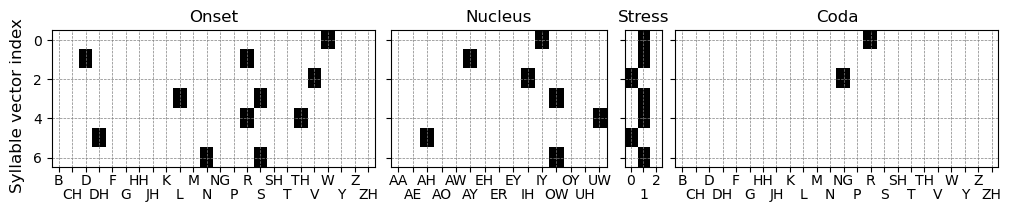

In [7]:
fig, ax = plt.subplots(figsize=(10, 2), nrows=1, ncols=4, width_ratios=[6, 4, 0.7, 6], sharey=True)
ax[0].imshow(song_sylphone_encode[:,conso_onset_idx], aspect='auto', cmap='gray_r'); ax[0].set_title('Onset');
ax[0].set_xticks(range(len(consonants_onset)));
# Get current tick locations and labels
plot_ticklabels(ax[0], consonants_onset)
ax[0].grid(which='major', linestyle='--', linewidth=0.5, color='gray')

ax[1].imshow(song_sylphone_encode[:,vowel_idx], aspect='auto', cmap='gray_r'); ax[1].set_title('Nucleus');
ax[1].set_xticks(range(len(vowels)));
plot_ticklabels(ax[1], vowels)
ax[1].grid(which='major', linestyle='--', linewidth=0.5, color='gray')

ax[2].imshow(song_sylphone_encode[:,stress_idx], aspect='auto', cmap='gray_r'); ax[2].set_title('Stress');
ax[2].set_xticks(range(len(stress)));
# ax[2].set_xticklabels(stress);
plot_ticklabels(ax[2], stress)
ax[2].grid(which='major', linestyle='--', linewidth=0.5, color='gray')

ax[3].imshow(song_sylphone_encode[:,conso_coda_idx], aspect='auto', cmap='gray_r'); ax[3].set_title('Coda');
ax[3].set_xticks(range(len(consonants_coda)));
# Get current tick locations and labels
plot_ticklabels(ax[3], consonants_coda)
ax[3].grid(which='major', linestyle='--', linewidth=0.5, color='gray')

fig.supylabel('Syllable vector index');
# plt.savefig('outputs/sylphone_example.pdf')
plt.show()